<a href="https://colab.research.google.com/github/heetaamin/ml-assignment2/blob/main/earlier_version/KNN_preprocessing_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# kNN Preprocessing Notebook — Cell 1: Setup & Load
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

# Update this path to match where networkTraffic.csv lives in your Drive
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 2/networkTraffic.csv'

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print(df.dtypes.value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (257673, 44)
int64      30
float64    11
object      3
Name: count, dtype: int64


In [ ]:
# ============================================================
# Cell 2: Structural drops (DQP-confirmed)
# ============================================================

# Work from a copy so issues when working with classification trees.
df_knn = df.copy()

# id: unique identifier, carries no predictive signal (DQP)
df_knn = df_knn.drop(columns=['id'])

# Documented/injected redundant pairs (DQP): for each pair, drop
# the derived/secondary feature and keep the direct primary
# measurement it's redundant with. kNN's Euclidean distance
# double-counts shared signal from correlated features, so these
# are removed before any distance-based step (scaling, CV,
# modelling).
df_knn = df_knn.drop(columns=['ct_ftp_cmd'])   # r=0.9989 with is_ftp_login
df_knn = df_knn.drop(columns=['sloss'])        # r=0.9958 with sbytes
df_knn = df_knn.drop(columns=['dloss'])        # r=0.9967 with dbytes

#  Exact functional redundancy (DQP): tcprtt = synack + ackdat
#  by definition — not just statistically correlated. Dropping
#  it loses zero information, since it's fully recoverable from
#  the two features it's already kept alongside.
df_knn = df_knn.drop(columns=['tcprtt'])

print("Shape after structural drops:", df_knn.shape)
print("Dropped so far: id, ct_ftp_cmd, sloss, dloss, tcprtt")

Shape after structural drops: (257673, 39)
Dropped so far: id, ct_ftp_cmd, sloss, dloss, tcprtt


In [ ]:
# ============================================================
# Cell 3: Invalid value recodes (DQP-confirmed)
# ============================================================

# state: single invalid category 'no' (1 occurrence, confirmed
# against features.csv in EDA Cell 17) — not a genuine state
# category, treated as a data-entry error. Recoded to the mode
# (FIN) rather than dropped, since dropping a single row loses
# no meaningful signal but recoding keeps it simple and avoids
# a one-row category surviving into one-hot encoding later.
state_mode = df_knn['state'].mode()[0]
print("state mode:", state_mode)
print("Rows with state == 'no':", (df_knn['state'] == 'no').sum())

df_knn['state'] = df_knn['state'].replace('no', state_mode)

# Confirm the fix
print("'no' still present?", (df_knn['state'] == 'no').any())

# is_ftp_login: valid values should be binary (0/1), but 26 rows
# hold 2 or 4 (DQP: "near-identical pattern to ct_ftp_cmd, treat
# as data entry error"). Recoded to the nearest valid binary
# value: 2 and 4 both represent "login occurred" more strongly
# than "no login", so recode both to 1 rather than 0.
print("\nis_ftp_login value counts before:")
print(df_knn['is_ftp_login'].value_counts())

df_knn['is_ftp_login'] = df_knn['is_ftp_login'].replace({2: 1, 4: 1})

print("\nis_ftp_login value counts after:")
print(df_knn['is_ftp_login'].value_counts())

state mode: FIN
Rows with state == 'no': 1
'no' still present? False

is_ftp_login value counts before:
is_ftp_login
0    254428
1      3219
4        16
2        10
Name: count, dtype: int64

is_ftp_login value counts after:
is_ftp_login
0    254428
1      3245
Name: count, dtype: int64


**Note on is_ftp_login recode:** The 26 invalid rows (values 2/4) were recoded to 1
rather than mode-imputed to 0, based on their exact match with nonzero ct_ftp_cmd
values in the same rows — FTP requires authentication before commands can be issued,
so a nonzero command count is strong evidence a login occurred. This evidence isn't
absolute: 2 rows in the dataset show the opposite inconsistency (is_ftp_login=0 with
ct_ftp_cmd=1), so the correlation is very strong but not a guaranteed logical rule.
These 2 rows are left as-is since they weren't part of the flagged 26 and fall outside
this specific data quality issue.

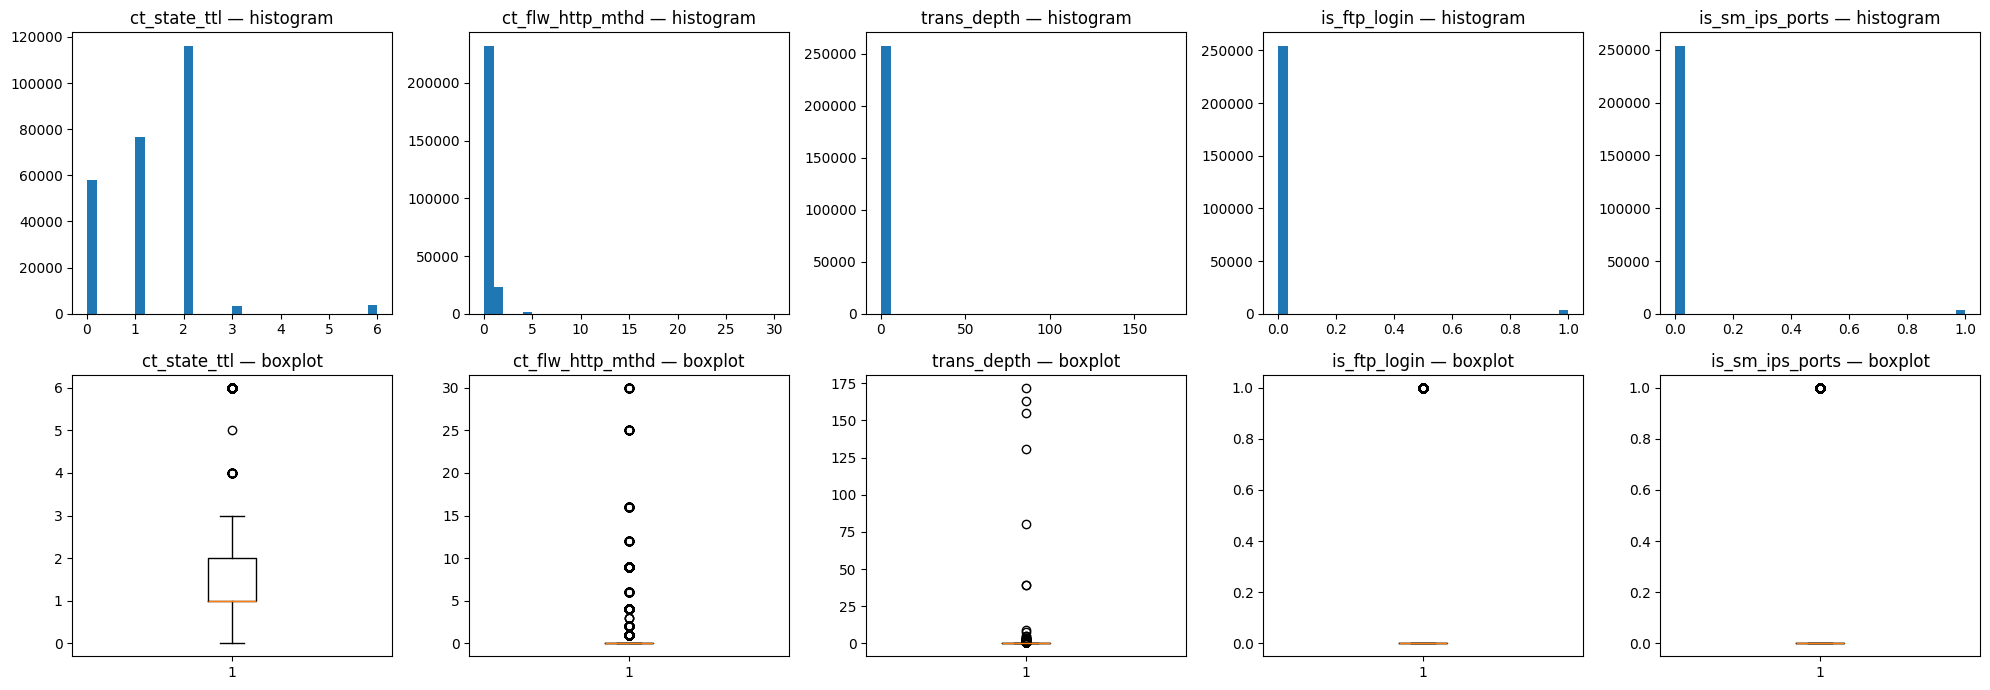

ct_state_ttl: Q1=1.0, Q3=2.0, IQR=1.0, unique values=7
ct_flw_http_mthd: Q1=0.0, Q3=0.0, IQR=0.0, unique values=11
trans_depth: Q1=0.0, Q3=0.0, IQR=0.0, unique values=14
is_ftp_login: Q1=0.0, Q3=0.0, IQR=0.0, unique values=2
is_sm_ips_ports: Q1=0.0, Q3=0.0, IQR=0.0, unique values=2


In [ ]:
# ============================================================
# Cell 4: Visual confirmation of borderline outlier candidates
# (per Topic 2 slide 57 — "look at the distribution of feature
# values" as a named outlier-identification technique)
# ============================================================
import matplotlib.pyplot as plt

check_cols = ['ct_state_ttl', 'ct_flw_http_mthd', 'trans_depth',
              'is_ftp_login', 'is_sm_ips_ports']

fig, axes = plt.subplots(2, 5, figsize=(20, 7))

for i, col in enumerate(check_cols):
    axes[0, i].hist(df_knn[col], bins=30)
    axes[0, i].set_title(f'{col} — histogram')

    axes[1, i].boxplot(df_knn[col])
    axes[1, i].set_title(f'{col} — boxplot')

plt.tight_layout()
plt.show()

# Print the actual quartiles so the IQR calc is visible, not just the plot
for col in check_cols:
    q1, q3 = df_knn[col].quantile([0.25, 0.75])
    print(f"{col}: Q1={q1}, Q3={q3}, IQR={q3-q1}, unique values={df_knn[col].nunique()}")

In [ ]:
# ============================================================
# Cell 5: Distribution shape check — remaining low-cardinality
# candidates, checked on RAW df (pre-clamp) to avoid the earlier
# stale-state mistake. Goal: sort each into "isolated extreme
# outliers" (clamping helps min-max resolution, per Lauren's
# question about what the transformation is actually FOR) vs.
# "recurring values" (clamping would erase real signal, same
# shape as ct_flw_http_mthd).
# ============================================================
low_card_cols = ['ct_state_ttl', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_src_ltm',
                  'ct_src_dport_ltm', 'ct_dst_ltm', 'ct_src_ltm', 'ct_dst_sport_ltm']

for col in low_card_cols:
    print(f"--- {col} ---")
    vc = df[col].value_counts().sort_index()
    print(vc.tail(10))
    print(f"max value: {df[col].max()}, rows at max: {(df[col]==df[col].max()).sum()}")
    print()

--- ct_state_ttl ---
ct_state_ttl
0     57836
1     76589
2    116154
3      3331
4        28
5         1
6      3734
Name: count, dtype: int64
max value: 6, rows at max: 3734

--- ct_srv_src ---
ct_srv_src
48     89
49    154
50    156
51    279
52    111
53     26
54     27
58     25
59     30
63     63
Name: count, dtype: int64
max value: 63, rows at max: 63

--- ct_srv_dst ---
ct_srv_dst
48    137
49    105
50    156
51    330
52     59
53     26
54     27
58     25
59     30
62     62
Name: count, dtype: int64
max value: 62, rows at max: 62

--- ct_dst_src_ltm ---
ct_dst_src_ltm
49    105
50    156
51    330
52     59
53     26
54     28
58     25
59     30
63     86
65      1
Name: count, dtype: int64
max value: 65, rows at max: 1

--- ct_src_dport_ltm ---
ct_src_dport_ltm
43    952
44      5
45     56
46     46
47     10
48      6
50     44
51     51
52      5
59     10
Name: count, dtype: int64
max value: 59, rows at max: 10

--- ct_dst_ltm ---
ct_dst_ltm
43    898
44     66
45


 NOTE TO SELF: why these features were removed from the
 original 27-feature clamp candidate list (down to 18)

 ct_state_ttl, ct_srv_src, ct_srv_dst, ct_dst_src_ltm,
 ct_src_dport_ltm, ct_dst_ltm, ct_src_ltm, ct_dst_sport_ltm,
 ct_flw_http_mthd:
   All "count" features. Checked their highest values (Cell 5
  diagnostic) and found dozens/hundreds of rows sitting at the
   max, not a single freak row. That means the high values are
   normal, recurring traffic patterns — not mistakes to correct.
   Clamping would flatten real signal, not fix a data quality
   issue.

 trans_depth:
   DOES look like a genuine outlier case (isolated one-off rows
   at 39, 80, 131, 155, 163, 172). But Lauren pushed back on
  picking a clamp bound (9) without evidence it actually helps
  the model, and pointed out clamping collapses very different
  values (39 vs 172) into one — a real cost that needs
  justifying, not assuming.   ACTION: build the rest of the pipeline first, then test
   clamped-at-9 vs. unclamped empirically (same k, same CV
   split) once there's a working kNN model to measure against.
  Come back to this before finalizing the report.


In [ ]:
# ============================================================
# Cell 5: Final clamp candidate list
# ============================================================
outlier_flagged = ['dload', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
    'ct_dst_ltm', 'dbytes', 'spkts', 'ct_srv_dst', 'dmean', 'smean', 'sbytes', 'dpkts',
    'djit', 'ct_src_ltm', 'ct_srv_src', 'ct_flw_http_mthd', 'trans_depth',
    'sjit', 'sload', 'dur', 'synack', 'sinpkt', 'dinpkt', 'response_body_len',
    'ackdat', 'ct_state_ttl']

# Recurring-values features: dense upper tails, not isolated extremes (Cell 5 diagnostic)
remove_recurring = ['ct_state_ttl', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_src_ltm',
    'ct_src_dport_ltm', 'ct_dst_ltm', 'ct_src_ltm', 'ct_dst_sport_ltm',
    'ct_flw_http_mthd','rate']

# Deferred to empirical testing per Lauren's feedback, not clamped on percentile alone
defer_to_evidence = ['trans_depth']

clamp_cols = [c for c in outlier_flagged if c not in remove_recurring + defer_to_evidence]

print(f"Clamping {len(clamp_cols)} features:")
print(clamp_cols)


Clamping 16 features:
['dload', 'dbytes', 'spkts', 'dmean', 'smean', 'sbytes', 'dpkts', 'djit', 'sjit', 'sload', 'dur', 'synack', 'sinpkt', 'dinpkt', 'response_body_len', 'ackdat']


In [ ]:
# ============================================================
# Cell 6: Clamp transformation (17 confirmed features)
# ============================================================
# Per Topic 2 slide 58 (robust estimators / clamp transformation).
# Applied BEFORE normalization, so min-max scaling isn't distorted
# by raw extremes. Standard 1%/99% percentile bounds — these are
# genuinely continuous magnitude features (not counts), so a
# percentile-based approach is appropriate here, unlike the
# count-type features excluded above.

LOWER_PCT = 0.01
UPPER_PCT = 0.99

clamp_bounds = {}
for col in clamp_cols:
    lower = df_knn[col].quantile(LOWER_PCT)
    upper = df_knn[col].quantile(UPPER_PCT)
    clamp_bounds[col] = (lower, upper)
    df_knn[col] = df_knn[col].clip(lower=lower, upper=upper)

bounds_df = pd.DataFrame(clamp_bounds, index=['lower_bound', 'upper_bound']).T
print(bounds_df)

                   lower_bound   upper_bound
dload                    0.000  1.443532e+07
dbytes                   0.000  3.699623e+05
spkts                    1.000  2.300000e+02
dmean                    0.000  1.252000e+03
smean                   45.000  1.137000e+03
sbytes                  46.000  7.258448e+04
dpkts                    0.000  3.680000e+02
djit                     0.000  9.341673e+03
sjit                     0.000  2.943241e+04
sload                    0.000  8.000000e+08
dur                      0.000  3.785372e+01
synack                   0.000  1.671050e-01
sinpkt                   0.001  6.000065e+04
dinpkt                   0.000  4.737246e+02
response_body_len        0.000  3.924000e+03
ackdat                   0.000  1.533996e-01


In [ ]:
# ============================================================
# Cell 6b: Systematic ceiling check for all 16 clamp candidates
# — same test that caught rate's problem, applied to the rest
# so we're not just trusting the others by association.
# ============================================================
for col in clamp_cols:
    upper = clamp_bounds[col][1]
    lower = clamp_bounds[col][0]

    rows_at_upper = (df[col] >= upper * 0.999).sum() if upper > 0 else (df[col] == upper).sum()
    rows_at_lower = (df[col] <= lower * 1.001).sum() if lower > 0 else (df[col] == lower).sum()

    print(f"{col:20s} | lower={lower:>14.4f} rows_near_lower={rows_at_lower:>7,} ({rows_at_lower/len(df)*100:5.2f}%) "
          f"| upper={upper:>14.4f} rows_near_upper={rows_at_upper:>7,} ({rows_at_upper/len(df)*100:5.2f}%)")

dload                | lower=        0.0000 rows_near_lower=120,303 (46.69%) | upper= 14435322.2000 rows_near_upper=  2,586 ( 1.00%)
dbytes               | lower=        0.0000 rows_near_lower=120,288 (46.68%) | upper=   369962.2800 rows_near_upper=  2,581 ( 1.00%)
spkts                | lower=        1.0000 rows_near_lower=  3,930 ( 1.53%) | upper=      230.0000 rows_near_upper=  2,615 ( 1.01%)
dmean                | lower=        0.0000 rows_near_lower=120,288 (46.68%) | upper=     1252.0000 rows_near_upper=  2,963 ( 1.15%)
smean                | lower=       45.0000 rows_near_lower=  5,540 ( 2.15%) | upper=     1137.0000 rows_near_upper=  3,319 ( 1.29%)
sbytes               | lower=       46.0000 rows_near_lower=  3,535 ( 1.37%) | upper=    72584.4800 rows_near_upper=  2,579 ( 1.00%)
dpkts                | lower=        0.0000 rows_near_lower=120,288 (46.68%) | upper=      368.0000 rows_near_upper=  2,582 ( 1.00%)
djit                 | lower=        0.0000 rows_near_lower=135,295 (

In [ ]:
# ============================================================
# Cell 6c: Precise ceiling check — rows tied at the EXACT max
# (this is what actually caught rate's problem, not the looser
# "near the bound" check from Cell 6b)
# ============================================================
for col in clamp_cols:
    true_max = df[col].max()
    rows_at_true_max = (df[col] == true_max).sum()
    print(f"{col:20s} | true_max={true_max:>16.4f} | rows tied at max={rows_at_true_max:>6,} "
          f"({rows_at_true_max/len(df)*100:5.3f}%)")

dload                | true_max=   22422730.0000 | rows tied at max=     1 (0.000%)
dbytes               | true_max=   14657531.0000 | rows tied at max=     1 (0.000%)
spkts                | true_max=      10646.0000 | rows tied at max=     1 (0.000%)
dmean                | true_max=       1500.0000 | rows tied at max=     1 (0.000%)
smean                | true_max=       1504.0000 | rows tied at max=     4 (0.002%)
sbytes               | true_max=   14355774.0000 | rows tied at max=     1 (0.000%)
dpkts                | true_max=      11018.0000 | rows tied at max=     1 (0.000%)
djit                 | true_max=     463199.2401 | rows tied at max=     2 (0.001%)
sjit                 | true_max=    1483830.9170 | rows tied at max=     2 (0.001%)
sload                | true_max= 5988000256.0000 | rows tied at max=     1 (0.000%)
dur                  | true_max=         60.0000 | rows tied at max=     6 (0.002%)
synack               | true_max=          3.2268 | rows tied at max=     1 (

 ADDENDUM: rate was initially in the clamp candidate list but excluded
 after checking — its apparent "outliers" were actually 4,240 rows
 (1.645%) tied at the exact same ceiling value (1000000.003), not# isolated extremes. Confirmed via exact-max-tie count, which is the
 correct diagnostic (checking "% near the bound" isn't sufficient,
 since ~1% near a 99th-percentile bound is expected by definition).
 All 16 features actually clamped were re-checked the same way and
 show only 1-6 rows tied at their true max — genuine isolated outliers.

In [ ]:
# ============================================================
# Cell 7: Check if stcpb/dtcpb actually matter
# ============================================================
# Simple check: does the average value of these two columns
# look different for different attack types? If yes, they're
# probably useful and worth keeping. If they all look about
# the same, they're probably not telling us much.

df_knn.groupby('attack_cat')[['stcpb', 'dtcpb']].mean()

,stcpb,dtcpb
attack_cat,,
0,1.491325e+09,1.480589e+09
1,1.066815e+09,1.079445e+09
2,3.078061e+08,2.952011e+08
3,4.356244e+08,4.325281e+08
4,1.326784e+09,1.329089e+09
5,5.035461e+08,4.955274e+08
6,1.368714e+09,1.365963e+09
7,2.007980e+09,1.808773e+09
8,1.077551e+09,1.080764e+09


Note: stcpb and dtcpb are included in this scaling step, since
we checked and decided to KEEP them (their averages genuinely
differ across attack types, so they carry real signal). Only trans_depth is excluded here, pending a separate decision.

In [ ]:
# ============================================================
# Cell 8: Put every column on the same scale
# ============================================================
# kNN measures "distance" between rows. If one column has
# values in the billions and another only goes up to 3, the
# billion-scale column would completely dominate that distance
# and drown out everything else. This step squashes every
# numeric column down to the same 0–1 range, so they're all
# treated fairly.
#
# trans_depth is left out for now — still deciding separately
# whether to cap it, so we don't want to lock in its scale yet.

from sklearn.preprocessing import MinMaxScaler

numeric_cols = df_knn.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_to_scale = [c for c in numeric_cols if c != 'trans_depth']

scaler = MinMaxScaler()
df_knn[numeric_cols_to_scale] = scaler.fit_transform(df_knn[numeric_cols_to_scale])

print("Scaled", len(numeric_cols_to_scale), "columns.")
print(df_knn[numeric_cols_to_scale].describe().loc[['min', 'max']])

Scaled 35 columns.
     dur  spkts  dpkts  sbytes  dbytes  rate  sttl  dttl  sload  dload  ...  \
min  0.0    0.0    0.0     0.0     0.0   0.0   0.0   0.0    0.0    0.0  ...   
max  1.0    1.0    1.0     1.0     1.0   1.0   1.0   1.0    1.0    1.0  ...   

     ct_dst_ltm  ct_src_dport_ltm  ct_dst_sport_ltm  ct_dst_src_ltm  \
min         0.0               0.0               0.0             0.0   
max         1.0               1.0               1.0             1.0   

     is_ftp_login  ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  is_sm_ips_ports  \
min           0.0               0.0         0.0         0.0              0.0   
max           1.0               1.0         1.0         1.0              1.0   

     attack_cat  
min         0.0  
max         1.0  

[2 rows x 35 columns]


In [ ]:
# ============================================================
# Fix: exclude attack_cat from scaling, restore the real labels
# ============================================================
# attack_cat is the target label, not a feature to scale — it
# got caught by mistake since it's stored as numbers (0-9).
# Restore the real values from the original df, then redo the
# scaling correctly this time.

df_knn['attack_cat'] = df['attack_cat'].values

numeric_cols = df_knn.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_to_scale = [c for c in numeric_cols if c not in ['trans_depth', 'attack_cat']]

scaler = MinMaxScaler()
df_knn[numeric_cols_to_scale] = scaler.fit_transform(df_knn[numeric_cols_to_scale])

print("Scaled", len(numeric_cols_to_scale), "columns.")
print("attack_cat values (should be 0-9, not decimals):", sorted(df_knn['attack_cat'].unique()))

Scaled 34 columns.
attack_cat values (should be 0-9, not decimals): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [ ]:
# ============================================================
# Cell: service missing values — add a flag
# ============================================================
# service is missing about 55% of the time, marked with '?'.
# Since so much is missing, guessing a value would be
# unreliable — instead we add a simple yes/no flag saying
# "was this row missing," so the model can use that fact
# itself if it turns out to matter.

df_knn['service_missing'] = (df_knn['service'] == '?').astype(int)

print("Rows flagged as missing:", df_knn['service_missing'].sum())
print("Percentage:", df_knn['service_missing'].mean() * 100)

Rows flagged as missing: 141321
Percentage: 54.845094363786664


In [ ]:
# ============================================================
# Cell: proto — bucket rare categories
# ============================================================
# proto has 133 different protocol values, but a handful of
# them (tcp, udp) cover almost all the data — most of the
# other 131 values probably only show up a few times each.
# One-hot encoding all 133 as-is would create 133 mostly-empty
# columns, which isn't useful and adds noise. Instead, we group
# anything below a chosen frequency threshold into "other".

# First, let's just look at the actual distribution before
# picking a threshold — same "check before deciding" approach
# as everything else so far.
proto_counts = df_knn['proto'].value_counts()
print(proto_counts.head(15))
print("...")
print(f"\nTotal categories: {len(proto_counts)}")
print(f"Categories with fewer than 100 rows: {(proto_counts < 100).sum()}")
print(f"Categories with fewer than 10 rows: {(proto_counts < 10).sum()}")

proto
tcp       123041
udp        92701
unas       15599
arp         3846
ospf        3271
sctp        1474
any          396
gre          313
rsvp         264
ipv6         262
sun-nd       255
pim          253
mobile       253
swipe        253
sep          251
Name: count, dtype: int64
...

Total categories: 133
Categories with fewer than 100 rows: 3
Categories with fewer than 10 rows: 1


In [ ]:
# ============================================================
# Check: is proto actually associated with attack_cat?
# ============================================================
# Cross-tab showing how attack types distribute across the
# top protocols, before deciding whether proto is worth
# keeping at all, or how to bucket it.
top_protos = df_knn['proto'].value_counts().head(10).index
pd.crosstab(df_knn[df_knn['proto'].isin(top_protos)]['proto'],
            df_knn[df_knn['proto'].isin(top_protos)]['attack_cat'],
            normalize='index').round(3)

attack_cat,0,1,2,3,4,5,6,7,8,9
proto,,,,,,,,,,
any,0.000,0.053,0.053,0.333,0.417,0.061,0.076,0.000,0.000,0.008
arp,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
gre,0.000,0.061,0.048,0.342,0.438,0.045,0.058,0.000,0.000,0.010
ipv6,0.000,0.053,0.046,0.321,0.469,0.034,0.061,0.000,0.000,0.015
ospf,0.031,0.070,0.050,0.289,0.460,0.023,0.064,0.000,0.000,0.014
rsvp,0.000,0.053,0.053,0.333,0.417,0.061,0.076,0.000,0.000,0.008
sctp,0.000,0.077,0.047,0.289,0.501,0.018,0.052,0.000,0.000,0.017
tcp,0.544,0.057,0.003,0.027,0.223,0.005,0.126,0.001,0.006,0.008
udp,0.238,0.053,0.000,0.006,0.009,0.000,0.065,0.000,0.008,0.621


In [ ]:
# ============================================================
# Cell: proto — bucket by cumulative share, not a guessed count
# ============================================================
# Rather than pick an arbitrary row-count cutoff, use a
# percentage of the data as the threshold: keep any protocol
# that makes up at least 1% of all connections as its own
# category; group everything smaller into "other". This ties
# the cutoff directly to what we just saw in the data, rather
# than an arbitrary round number.

threshold = 0.01 * len(df_knn)  # 1% of all rows
keep_protos = proto_counts[proto_counts >= threshold].index.tolist()

print(f"Threshold: {threshold:.0f} rows")
print(f"Protocols kept as their own category ({len(keep_protos)}):")
print(keep_protos)
print(f"\nRows going into 'other': {(~df_knn['proto'].isin(keep_protos)).sum()} "
      f"({(~df_knn['proto'].isin(keep_protos)).mean()*100:.2f}%)")

df_knn['proto'] = df_knn['proto'].where(df_knn['proto'].isin(keep_protos), 'other')
print("\nFinal proto value counts:")
print(df_knn['proto'].value_counts())

Threshold: 2577 rows
Protocols kept as their own category (5):
['tcp', 'udp', 'unas', 'arp', 'ospf']

Rows going into 'other': 19215 (7.46%)

Final proto value counts:
proto
tcp      123041
udp       92701
other     19215
unas      15599
arp        3846
ospf       3271
Name: count, dtype: int64


In [ ]:
# ============================================================
# Cell: One-hot encode proto, state, service
# ============================================================
# These three columns hold category names (like "tcp" or "FIN"),
# not numbers, so kNN's distance calculation can't use them
# directly. One-hot encoding turns each category into its own
# yes/no (0/1) column instead — e.g. proto_tcp, proto_udp, etc.
# service's '?' becomes its own column too, same as any other
# category — that's the second half of the missing-value plan
# from before (the flag column handles "was it missing", this
# handles "what do we do with the actual value").

nominal_cols = ['proto', 'state', 'service']

print("Columns before encoding:", df_knn.shape[1])

df_knn = pd.get_dummies(df_knn, columns=nominal_cols)

print("Columns after encoding:", df_knn.shape[1])

Columns before encoding: 40
Columns after encoding: 66


In [ ]:
print("proto columns:", [c for c in df_knn.columns if c.startswith('proto_')])
print("state columns:", [c for c in df_knn.columns if c.startswith('state_')])
print("service columns:", [c for c in df_knn.columns if c.startswith('service_')])

proto columns: ['proto_arp', 'proto_ospf', 'proto_other', 'proto_tcp', 'proto_udp', 'proto_unas']
state columns: ['state_ACC', 'state_CLO', 'state_CON', 'state_ECO', 'state_FIN', 'state_INT', 'state_PAR', 'state_REQ', 'state_RST', 'state_URN']
service columns: ['service_missing', 'service_?', 'service_dhcp', 'service_dns', 'service_ftp', 'service_ftp-data', 'service_http', 'service_irc', 'service_pop3', 'service_radius', 'service_smtp', 'service_snmp', 'service_ssh', 'service_ssl']


In [ ]:
# ============================================================
# Cell: Drop duplicate service column
# ============================================================
# How this duplicate happened: two separate steps each created
# a "service was missing" column without knowing about each
# other. First, we manually made service_missing by checking
# for '?' directly. Later, one-hot encoding automatically made
# a column for every distinct value still in the service column
# — including '?' itself, since we never removed it (the plan
# was always to let '?' become its own category). Both columns
# ended up meaning the exact same thing, just built two
# different ways.
#
# service_missing and service_? are identical — both are 1
# exactly when service was originally '?'. Keeping both
# double-counts the same signal. Keep service_missing, drop
# service_?.
assert (df_knn['service_missing'] == df_knn['service_?']).all(), "not actually identical — check before dropping"
df_knn = df_knn.drop(columns=['service_?'])
print("service columns now:", [c for c in df_knn.columns if c.startswith('service_')])
print("Shape:", df_knn.shape)

service columns now: ['service_missing', 'service_dhcp', 'service_dns', 'service_ftp', 'service_ftp-data', 'service_http', 'service_irc', 'service_pop3', 'service_radius', 'service_smtp', 'service_snmp', 'service_ssh', 'service_ssl']
Shape: (257673, 65)


# NOTE:
connection-count cluster (ct_srv_src, ct_srv_dst,
ct_dst_src_ltm, ct_src_dport_ltm, ct_dst_ltm, ct_src_ltm,ct_dst_sport_ltm) — 7 features, mutually correlated |r|>0.9.
Deferred to a wrapper-method test (Topic 2 slide 16: build
baseline model, compare performance with/without candidate features) once the kNN pipeline exists — same approach as
trans_depth. Not resolved by inspection alone, since dropping
pairs one at a time doesn't cleanly handle a mutual cluster
like this.

In [ ]:
# ============================================================
# Cell: Verify duplicates actually exist before removing them
# ============================================================
# Check against df_knn as it stands right now — after all the
# column changes so far, not just trusting the original EDA
# number, since dropping columns can sometimes make previously
# distinct rows look identical (or vice versa).

n_dupes = df_knn.duplicated().sum()
print(f"Duplicate rows in current df_knn: {n_dupes} ({n_dupes/len(df_knn)*100:.2f}%)")

# Also check against attack_cat specifically, to confirm the
# "concentrated in Generic/DoS" pattern still holds
dupe_mask = df_knn.duplicated(keep=False)
print("\nClass distribution among duplicated rows:")
print(df_knn[dupe_mask]['attack_cat'].value_counts(normalize=True).sort_index())

Duplicate rows in current df_knn: 96690 (37.52%)

Class distribution among duplicated rows:
attack_cat
0    0.094515
1    0.045615
2    0.009641
3    0.109931
4    0.185241
5    0.012953
6    0.048346
7    0.000052
8    0.000858
9    0.492847
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# Cell: Confirm why duplicate count increased
# ============================================================
# Check duplicates on the ORIGINAL raw columns still present in
# df_knn (i.e. columns that existed in df before any transforms),
# vs. the full current column set. If dropping columns and
# clamping are really the cause, restricting the check to a
# comparable subset should land closer to the original 36.8%.

original_present_cols = [c for c in df.columns if c in df_knn.columns]
n_dupes_original_cols = df_knn.duplicated(subset=original_present_cols).sum()
print(f"Duplicates using only original (unmodified-name) columns: "
      f"{n_dupes_original_cols} ({n_dupes_original_cols/len(df_knn)*100:.2f}%)")

n_dupes_full = df_knn.duplicated().sum()
print(f"Duplicates using ALL current columns (incl. new one-hot/flag cols): "
      f"{n_dupes_full} ({n_dupes_full/len(df_knn)*100:.2f}%)")

Duplicates using only original (unmodified-name) columns: 97434 (37.81%)
Duplicates using ALL current columns (incl. new one-hot/flag cols): 96690 (37.52%)


In [ ]:
# ============================================================
# Cell: Remove duplicate rows
# ============================================================
print("Shape before dedup:", df_knn.shape)
print("\nClass distribution before dedup:")
print(df_knn['attack_cat'].value_counts().sort_index())

df_knn = df_knn.drop_duplicates()

print("\nShape after dedup:", df_knn.shape)
print("\nClass distribution after dedup:")
print(df_knn['attack_cat'].value_counts().sort_index())

Shape before dedup: (257673, 65)

Class distribution before dedup:
attack_cat
0    93000
1    13987
2     2329
3    16353
4    44525
5     2677
6    24246
7      174
8     1511
9    58871
Name: count, dtype: int64

Shape after dedup: (160983, 65)

Class distribution after dedup:
attack_cat
0    85487
1     9745
2     1678
3     5236
4    27170
5     1770
6    20698
7      171
8     1456
9     7572
Name: count, dtype: int64


In [ ]:
# ============================================================
# Save the preprocessed kNN dataset
# ============================================================
df_knn.to_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 2/networkTraffic_knn_preprocessed.csv', index=False)
print("Saved. Shape:", df_knn.shape)

Saved. Shape: (160983, 65)
